In [1]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# === 1. Load all .txt result files ===
results_folder = "results_acc"
prompt_results = {}

for file in os.listdir(results_folder):
    if file.endswith(".txt"):
        prompt_name = os.path.splitext(file)[0]
        with open(os.path.join(results_folder, file), "r", encoding="utf-8") as f:
            text = f.read()
            start = text.find("{")
            end = text.rfind("}") + 1
            if start != -1 and end != -1:
                data_str = text[start:end]
                try:
                    data_dict = ast.literal_eval(data_str)
                    prompt_results[prompt_name] = data_dict
                except Exception as e:
                    print(f"⚠️ Error parsing {file}: {e}")

# === 2. Separate subject-level and discipline-level ===
subject_records = []
discipline_records = []

for prompt, result_dict in prompt_results.items():
    for key, value in result_dict.items():
        if key == "Overall":
            continue
        acc = value.get("acc", np.nan)
        num = value.get("num", np.nan)
        
        if key.startswith("Overall-"):
            discipline = key.replace("Overall-", "")
            discipline_records.append({
                "Prompt": prompt, 
                "Discipline": discipline, 
                "Accuracy": acc, 
                "Num": num
            })
        else:
            subject_records.append({
                "Prompt": prompt, 
                "Subject": key, 
                "Accuracy": acc, 
                "Num": num
            })

df_subject = pd.DataFrame(subject_records)
df_discipline = pd.DataFrame(discipline_records)

print("✅ Subjects:", df_subject.shape, "| Disciplines:", df_discipline.shape)

# === 3. Summary statistics ===
subject_summary = (
    df_subject.groupby("Prompt")["Accuracy"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "Mean_Accuracy", "std": "SD"})
)

discipline_summary = (
    df_discipline.groupby("Prompt")["Accuracy"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "Mean_Accuracy", "std": "SD"})
)

display(subject_summary.head())
display(discipline_summary.head())

✅ Subjects: (330, 4) | Disciplines: (66, 4)


,Prompt,Mean_Accuracy,SD
0,A1,0.374533,0.148217
1,A2,0.370033,0.149407
2,A3,0.348833,0.156307
3,A4,0.359933,0.164275
4,A5,0.352333,0.147393


,Prompt,Mean_Accuracy,SD
0,A1,0.387500,0.113027
1,A2,0.381667,0.117238
2,A3,0.368333,0.135469
3,A4,0.377167,0.135775
4,A5,0.364500,0.110041


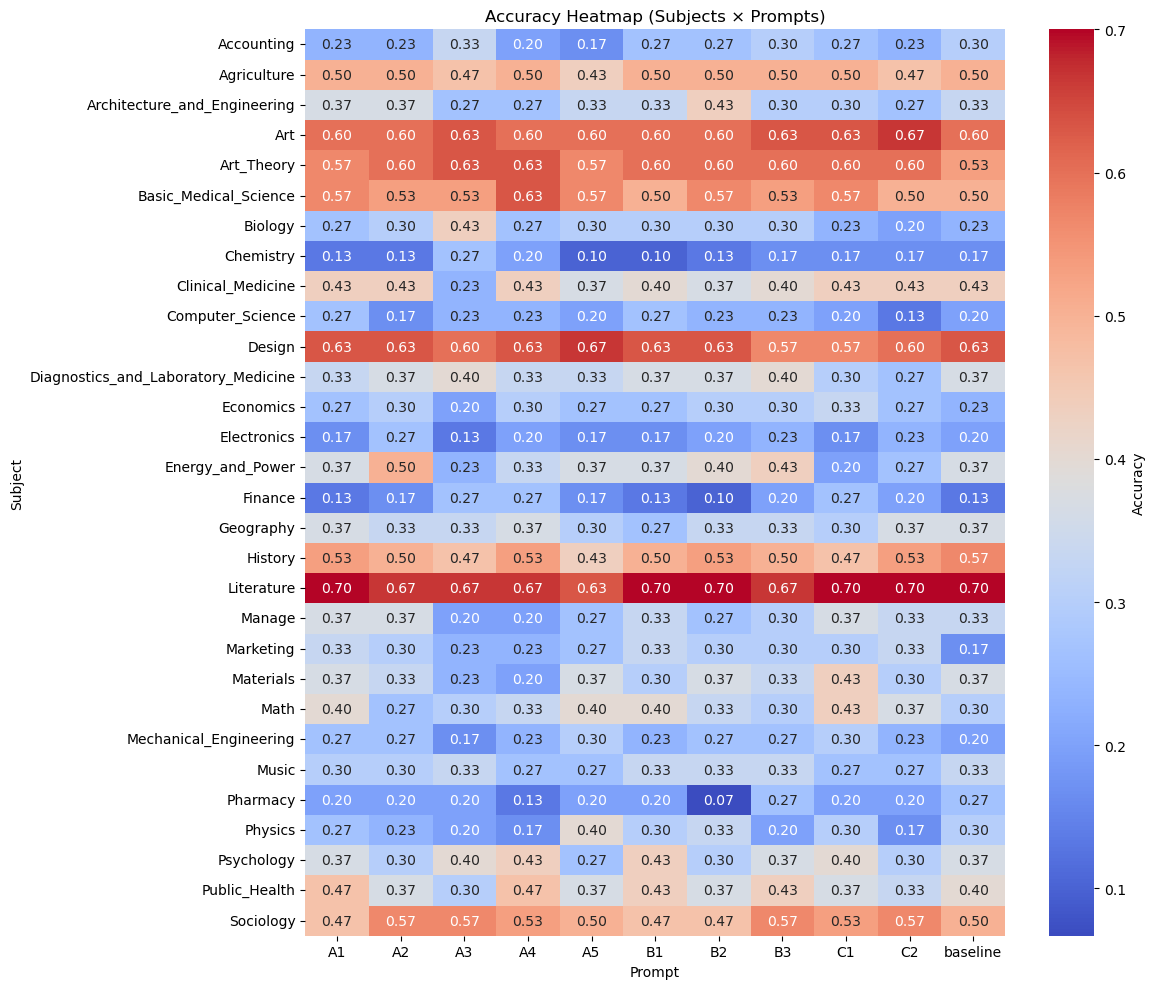

In [3]:
# === 6. Heatmap: Subject × Prompt ===
pivot_subject = df_subject.pivot(index="Subject", columns="Prompt", values="Accuracy")
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_subject, annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': 'Accuracy'})
plt.title("Accuracy Heatmap (Subjects × Prompts)")
plt.tight_layout()
plt.show()

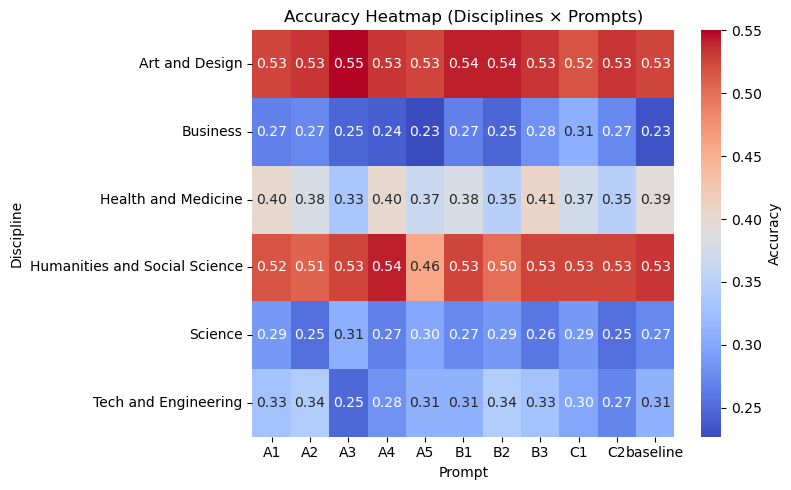

In [4]:
# === 7. Heatmap: Discipline × Prompt ===
pivot_discipline = df_discipline.pivot(index="Discipline", columns="Prompt", values="Accuracy")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_discipline, annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': 'Accuracy'})
plt.title("Accuracy Heatmap (Disciplines × Prompts)")
plt.tight_layout()
plt.show()

# Overall Performance Table


In [ ]:
df_discipline.to_excel("df_discipline.xlsx", index=False)
discipline_summary.to_excel("discipline_summary.xlsx", index=False)

In [26]:
discipline_summary

,Prompt,Mean_Accuracy,SD,Delta
0,A1,0.387500,0.113027,0.008917
1,A2,0.381667,0.117238,0.003083
2,A3,0.368333,0.135469,-0.010250
3,A4,0.377167,0.135775,-0.001417
4,A5,0.364500,0.110041,-0.014083
5,B1,0.382833,0.123563,0.004250
6,B2,0.377667,0.117820,-0.000917
7,B3,0.389000,0.119731,0.010417


First - Bold, Second - Underscore
- accuracy per discipline per prompt
- accuracy per prompt
- SD

# Sensitivity

In [6]:
# === 1. Calculate global mean accuracy ===
global_mean = df_discipline["Accuracy"].mean()

# === 2. Compute sensitivity metrics at discipline level ===
sensitivity = (
    df_discipline.groupby("Prompt")["Accuracy"]
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
    .rename(columns={'mean': 'Mean_Accuracy', 'std': 'SD'})
)

# Coefficient of Variation (CV)
sensitivity["CV"] = sensitivity["SD"] / sensitivity["Mean_Accuracy"]

# POSIX-like Prompt Sensitivity Index (scaled by global mean)
sensitivity["POSIX"] = sensitivity["SD"] / global_mean

# Prompt Sensitivity Score (PSS = 1 - CV)
sensitivity["PSS"] = 1 - sensitivity["CV"]

# Optimal Prompt Gap (OPG = max - min)
sensitivity["OPG"] = sensitivity["max"] - sensitivity["min"]

# Round for readability
sensitivity = sensitivity.round(4)

print("=== Prompt Sensitivity Metrics (Discipline Level) ===")
display(sensitivity)

=== Prompt Sensitivity Metrics (Discipline Level) ===


,Prompt,Mean_Accuracy,SD,min,max,CV,POSIX,PSS,OPG
0,A1,0.3875,0.1130,0.267,0.525,0.2917,0.2990,0.7083,0.258
1,A2,0.3817,0.1172,0.253,0.533,0.3072,0.3101,0.6928,0.280
2,A3,0.3683,0.1355,0.247,0.550,0.3678,0.3584,0.6322,0.303
3,A4,0.3772,0.1358,0.240,0.542,0.3600,0.3592,0.6400,0.302
4,A5,0.3645,0.1100,0.227,0.525,0.3019,0.2911,0.6981,0.298
5,B1,0.3828,0.1236,0.267,0.542,0.3228,0.3269,0.6772,0.275
6,B2,0.3777,0.1178,0.247,0.542,0.3120,0.3117,0.6880,0.295
7,B3,0.3890,0.1197,0.260,0.533,0.3078,0.3167,0.6922,0.273
8,C1,0.3848,0.1096,0.287,0.525,0.2848,0.2900,0.7152,0.238
9,C2,0.3670,0.1296,0.253,0.533,0.3531,0.3428,0.6469,0.280


In [9]:
sensitivity.to_excel("sensitivity.xlsx", index=False)

In [10]:
stable_prompts = sensitivity.sort_values("PSS", ascending=False)[["Prompt", "PSS", "CV", "SD", "POSIX", "OPG"]]
print("=== Most Stable Prompts (High PSS) ===")
display(stable_prompts.head())

print("=== Most Sensitive Prompts (Low PSS) ===")
display(stable_prompts.tail())

=== Most Stable Prompts (High PSS) ===


,Prompt,PSS,CV,SD,POSIX,OPG
8,C1,0.7152,0.2848,0.1096,0.2900,0.238
0,A1,0.7083,0.2917,0.1130,0.2990,0.258
4,A5,0.6981,0.3019,0.1100,0.2911,0.298
1,A2,0.6928,0.3072,0.1172,0.3101,0.280
7,B3,0.6922,0.3078,0.1197,0.3167,0.273


=== Most Sensitive Prompts (Low PSS) ===


,Prompt,PSS,CV,SD,POSIX,OPG
5,B1,0.6772,0.3228,0.1236,0.3269,0.275
10,baseline,0.6600,0.3400,0.1285,0.3399,0.300
9,C2,0.6469,0.3531,0.1296,0.3428,0.280
3,A4,0.6400,0.3600,0.1358,0.3592,0.302
2,A3,0.6322,0.3678,0.1355,0.3584,0.303


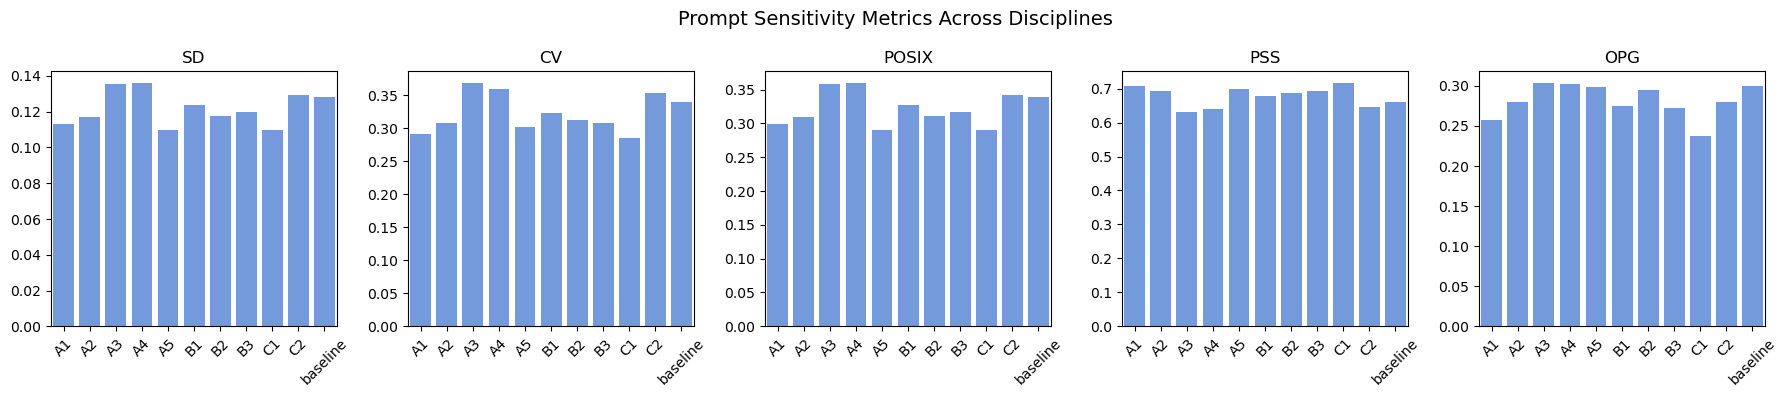

In [8]:
# === 3. Visualization: sensitivity metrics per prompt ===
metrics = ["SD", "CV", "POSIX", "PSS", "OPG"]
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))

for i, metric in enumerate(metrics):
    sns.barplot(x="Prompt", y=metric, data=sensitivity, ax=axes[i], color="cornflowerblue")
    axes[i].set_title(metric)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Prompt Sensitivity Metrics Across Disciplines", fontsize=14)
plt.tight_layout()
plt.show()
